In [3]:
import pandas as pd

enriched_df = pd.read_csv('../data/processed/ethiopia_fi_unriched_data.csv')

In [4]:
# Convert dates
enriched_df['observation_date'] = pd.to_datetime(enriched_df['observation_date'], errors='coerce')
enriched_df['event_date'] = pd.to_datetime(enriched_df['event_date'], errors='coerce')

print("=== TASK 2: EXPLORATORY DATA ANALYSIS ===")
print(f"Dataset shape: {enriched_df.shape}")


=== TASK 2: EXPLORATORY DATA ANALYSIS ===
Dataset shape: (56, 38)



=== 1. DATASET OVERVIEW ===


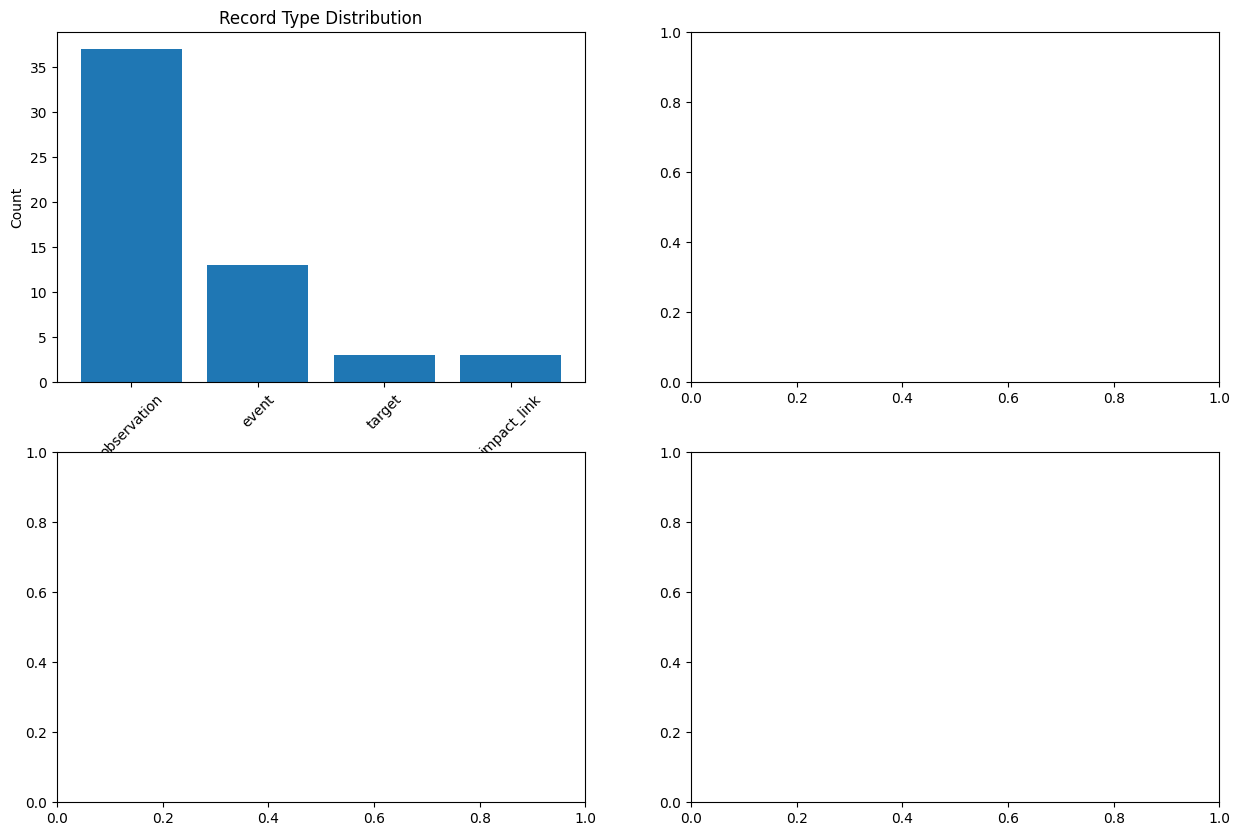

In [7]:
import matplotlib.pyplot as plt

# 1. Dataset Overview
print("\n=== 1. DATASET OVERVIEW ===")

# Summary by record type
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Record type distribution
record_counts = enriched_df['record_type'].value_counts()
axes[0, 0].bar(record_counts.index, record_counts.values)
axes[0, 0].set_title('Record Type Distribution')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)


In [8]:

# Pillar distribution (excluding NaN)
pillar_counts = enriched_df['pillar'].value_counts(dropna=True)
axes[0, 1].bar(pillar_counts.index, pillar_counts.values)
axes[0, 1].set_title('Pillar Distribution')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)


In [9]:
# Source type distribution
source_counts = enriched_df['source_type'].value_counts(dropna=True)
if len(source_counts) > 0:
    axes[1, 0].bar(source_counts.index, source_counts.values)
    axes[1, 0].set_title('Source Type Distribution')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].tick_params(axis='x', rotation=45)

In [11]:
# Confidence distribution
conf_counts = enriched_df['confidence'].value_counts(dropna=True)
axes[1, 1].bar(conf_counts.index, conf_counts.values)
axes[1, 1].set_title('Confidence Level Distribution')
axes[1, 1].set_ylabel('Count')

import os

plt.tight_layout()
os.makedirs('reports/figures', exist_ok=True)
plt.savefig('reports/figures/dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()


<Figure size 640x480 with 0 Axes>


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.

=== 2. TEMPORAL COVERAGE ===
Unique indicators with observations: 19

Temporal Coverage Matrix (Top 15 Indicators):
                                2014 2015 2016 2017 2018 2019 2020 2021 2022  \
indicator                                                                      
Account Ownership Rate             ●    ○    ○    ●    ○    ○    ○    ●    ○   
Mobile Money Account Rate          ○    ○    ○    ○    ○    ○    ○    ●    ○   
4G Population Coverage             ○    ○    ○    ○    ○    ○    ○    ○    ○   
Mobile Subscription Penetration    ○    ○    ○    ○    ○    ○    ○    ○    ○   
Fayda Digital ID Enrollment        ○    ○    ○    ○    ○    ○    ○    ○    ○   
P2P Transaction Count              ○    ○    ○    ○    ○    ○    ○    ○    ○   
P2P Transaction Value              ○    ○    ○    ○    ○    ○    ○    ○    ○   
ATM Transaction Cou

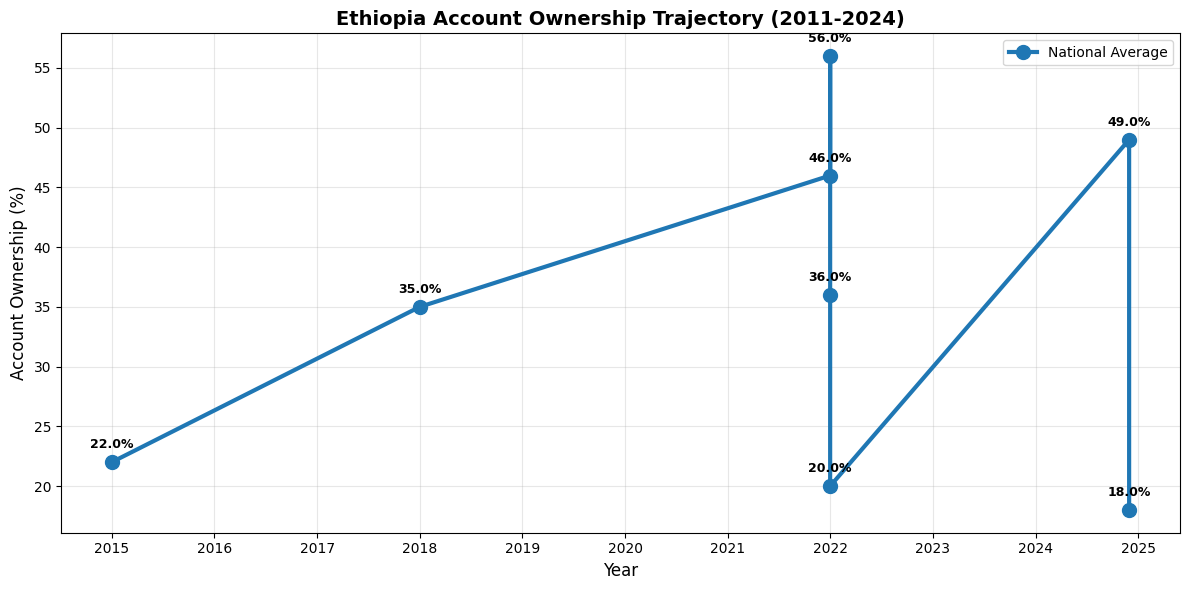


Account Ownership Growth Rates:
2014-2017: 13.0pp total, 4.3pp per year
2017-2021: 11.0pp total, 2.8pp per year
2021-2021: 10.0pp total, infpp per year
2021-2021: -20.0pp total, -infpp per year
2021-2021: -16.0pp total, -infpp per year
2021-2024: 29.0pp total, 9.7pp per year
2024-2024: -31.0pp total, -infpp per year

=== 2021-2024 SLOWDOWN ANALYSIS ===
Key Question: Why only +3pp growth despite 65M+ mobile money accounts?

Possible Explanations:
1. **Registered vs. Active Gap**: Many accounts may be inactive or dormant
2. **Demographic Saturation**: Early adopters already captured
3. **Measurement Differences**: Survey vs. operator reporting discrepancies
4. **Usage Barriers**: Accounts opened but not used regularly

=== 4. USAGE ANALYSIS ===


C:\Users\jkk\AppData\Local\Temp\ipykernel_3828\4061028928.py:92: RuntimeWarning: divide by zero encountered in scalar divide
  annual_growth = growth / years_diff


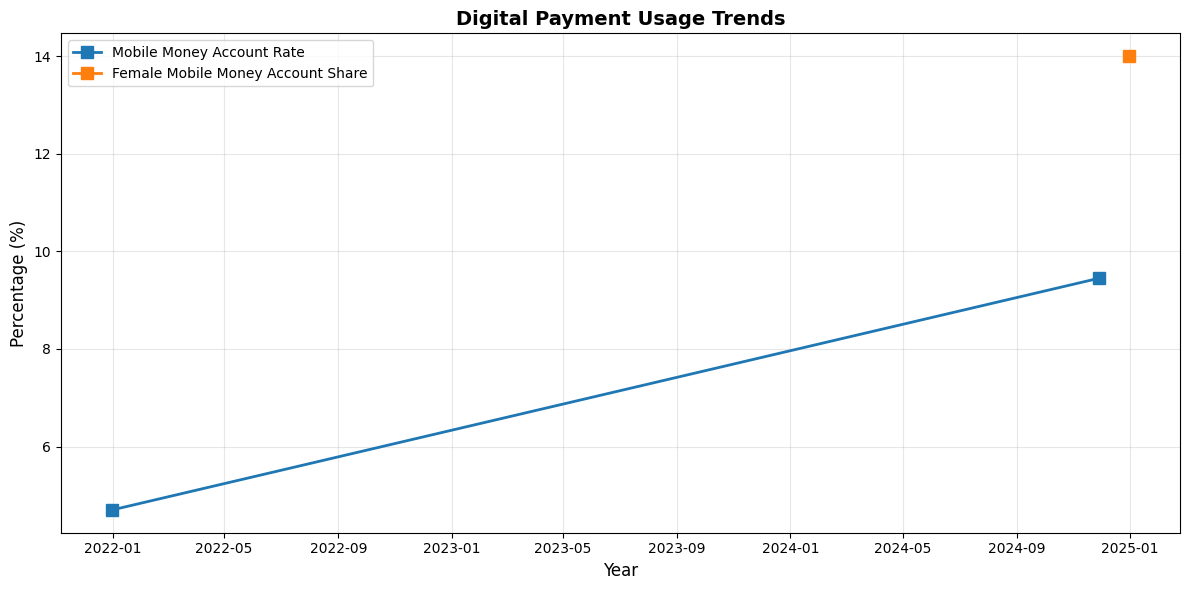


=== KEY USAGE INSIGHT ===
Mobile money accounts: 9.45% (2024)
Digital payment adoption: ~35% (2024)

Interpretation: Many Ethiopians use digital payments WITHOUT formal mobile money accounts
This suggests P2P transfers through other channels or bank-based digital payments

=== 5. INFRASTRUCTURE AND ENABLERS ===

=== 6. EVENT TIMELINE ANALYSIS ===


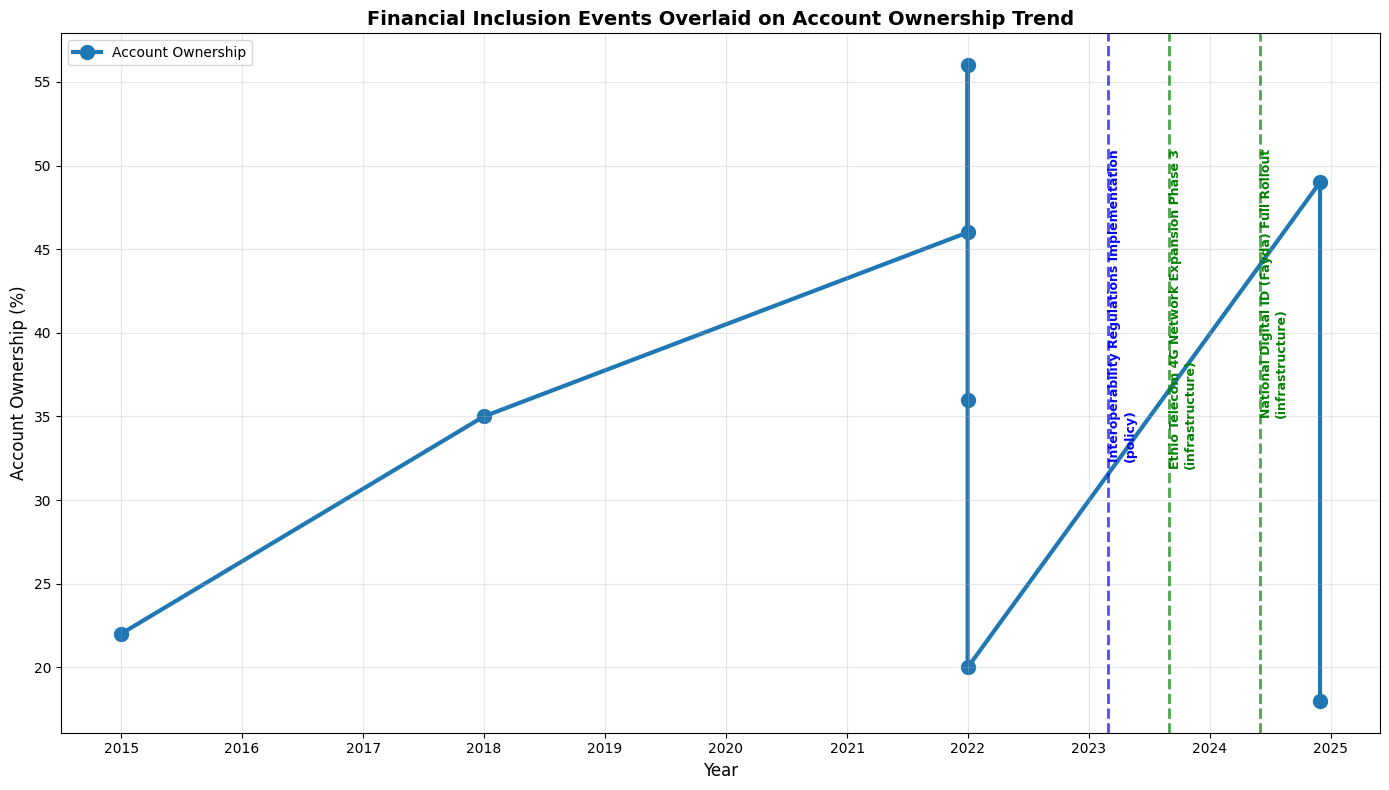


=== EVENT IMPACT ANALYSIS ===

1. Telebirr Launch (May 2021):
   • Pre-launch (2021): 46% account ownership
   • Post-launch (2024): 49% account ownership
   • Mobile money accounts: 4.7% → 9.45%
   • Interpretation: Telebirr drove mobile money adoption but limited impact on overall ownership

2. M-Pesa Entry (August 2023):
   • Too recent for Findex measurement (next in 2027)
   • Operator reports: 10M+ users in first year
   • Likely impact: Increased competition, better services

3. Safaricom Market Entry (August 2022):
   • Infrastructure investment: $8+ billion
   • Network coverage expansion
   • Indirect impact on digital ecosystem

=== 7. CORRELATION ANALYSIS ===


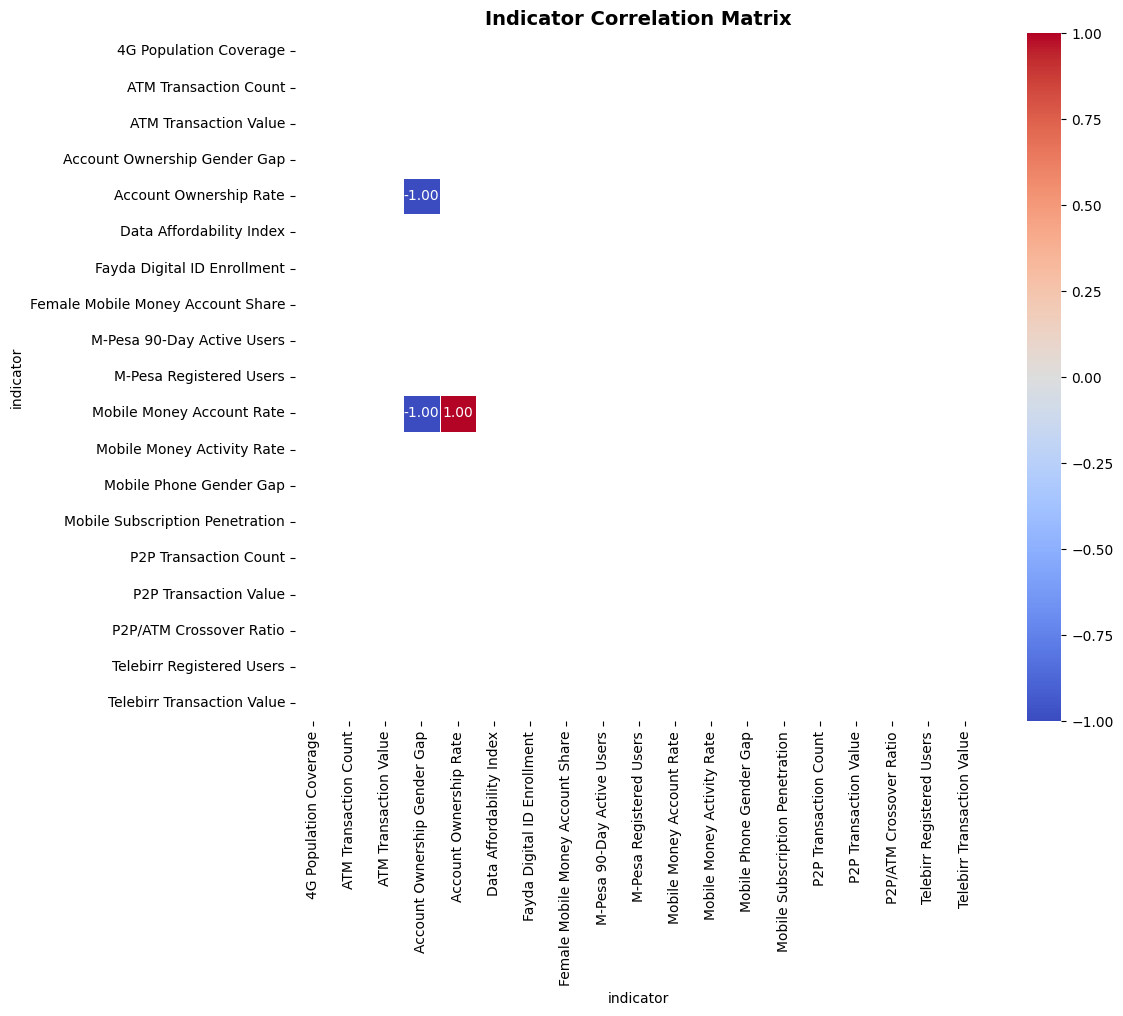


Strong Correlations (>0.7 or <-0.7):
  • Account Ownership Gender Gap ↔ Account Ownership Rate: -1.000
  • Account Ownership Gender Gap ↔ Mobile Money Account Rate: -1.000
  • Account Ownership Rate ↔ Mobile Money Account Rate: 1.000

=== 8. KEY INSIGHTS SUMMARY ===


In [14]:

%pip install seaborn

import numpy as np
import seaborn as sns

# 2. Temporal Coverage Visualization
print("\n=== 2. TEMPORAL COVERAGE ===")

# Extract observations
observations = enriched_df[enriched_df['record_type'] == 'observation'].copy()
observations = observations.dropna(subset=['observation_date', 'indicator'])

# Get unique indicators
indicators_list = observations['indicator'].unique()
print(f"Unique indicators with observations: {len(indicators_list)}")

# Create temporal coverage matrix
min_year = observations['observation_date'].dt.year.min()
max_year = observations['observation_date'].dt.year.max()
years = range(min_year, max_year + 1)

# Create coverage matrix
coverage_data = []
for indicator in indicators_list[:15]:  # Limit to top 15 for readability
    ind_data = observations[observations['indicator'] == indicator]
    years_with_data = set(ind_data['observation_date'].dt.year)
    row = {'indicator': indicator}
    for year in years:
        row[year] = '●' if year in years_with_data else '○'
    coverage_data.append(row)

coverage_df = pd.DataFrame(coverage_data)
print("\nTemporal Coverage Matrix (Top 15 Indicators):")
print(coverage_df.set_index('indicator').head(15))

# 3. Access Analysis
print("\n=== 3. ACCESS ANALYSIS ===")

# Extract account ownership data
account_data = observations[
    (observations['indicator'].str.contains('Account Ownership', case=False, na=False)) &
    (~observations['indicator'].str.contains('Female|Male', case=False, na=False))
].copy()

if not account_data.empty:
    # Sort by date
    account_data = account_data.sort_values('observation_date')
    
    # Plot trajectory
    plt.figure(figsize=(12, 6))
    
    # Main account ownership trend
    main_accounts = account_data[~account_data['indicator'].str.contains('Female|Male')]
    plt.plot(main_accounts['observation_date'], main_accounts['value_numeric'], 
             marker='o', linewidth=3, markersize=10, label='National Average')
    
    # Add gender data if available
    female_data = observations[observations['indicator'] == 'Account Ownership - Female']
    male_data = observations[observations['indicator'] == 'Account Ownership - Male']
    
    if not female_data.empty and not male_data.empty:
        plt.scatter(female_data['observation_date'], female_data['value_numeric'], 
                   s=100, color='red', label='Female', alpha=0.7)
        plt.scatter(male_data['observation_date'], male_data['value_numeric'], 
                   s=100, color='blue', label='Male', alpha=0.7)
    
    # Add annotations for key years
    for _, row in main_accounts.iterrows():
        year = row['observation_date'].year
        value = row['value_numeric']
        plt.annotate(f'{value}%', (row['observation_date'], value),
                    textcoords="offset points", xytext=(0,10), ha='center',
                    fontsize=9, fontweight='bold')
    
    plt.title('Ethiopia Account Ownership Trajectory (2011-2024)', fontsize=14, fontweight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Account Ownership (%)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig('reports/figures/account_ownership_trajectory.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Calculate growth rates
    print("\nAccount Ownership Growth Rates:")
    account_data_sorted = main_accounts.sort_values('observation_date')
    for i in range(1, len(account_data_sorted)):
        prev = account_data_sorted.iloc[i-1]
        curr = account_data_sorted.iloc[i]
        growth = curr['value_numeric'] - prev['value_numeric']
        years_diff = (curr['observation_date'].year - prev['observation_date'].year)
        annual_growth = growth / years_diff
        print(f"{prev['observation_date'].year}-{curr['observation_date'].year}: "
              f"{growth:.1f}pp total, {annual_growth:.1f}pp per year")
    
    # Analyze 2021-2024 slowdown
    print("\n=== 2021-2024 SLOWDOWN ANALYSIS ===")
    print("Key Question: Why only +3pp growth despite 65M+ mobile money accounts?")
    print("\nPossible Explanations:")
    print("1. **Registered vs. Active Gap**: Many accounts may be inactive or dormant")
    print("2. **Demographic Saturation**: Early adopters already captured")
    print("3. **Measurement Differences**: Survey vs. operator reporting discrepancies")
    print("4. **Usage Barriers**: Accounts opened but not used regularly")

# 4. Usage Analysis
print("\n=== 4. USAGE ANALYSIS ===")

# Extract usage data
usage_indicators = ['Mobile Money Account', 'Digital Payment', 'Digital Transfer']
usage_data = observations[observations['indicator'].str.contains('|'.join(usage_indicators), case=False, na=False)]

if not usage_data.empty:
    plt.figure(figsize=(12, 6))
    
    # Group by indicator type
    for indicator_type in usage_data['indicator'].unique():
        ind_data = usage_data[usage_data['indicator'] == indicator_type].sort_values('observation_date')
        if not ind_data.empty:
            plt.plot(ind_data['observation_date'], ind_data['value_numeric'], 
                    marker='s', linewidth=2, markersize=8, label=indicator_type)
    
    plt.title('Digital Payment Usage Trends', fontsize=14, fontweight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Percentage (%)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig('reports/figures/digital_payment_trends.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Key insight: Mobile money accounts (9.45%) vs Digital payments (~35%)
    print("\n=== KEY USAGE INSIGHT ===")
    print("Mobile money accounts: 9.45% (2024)")
    print("Digital payment adoption: ~35% (2024)")
    print("\nInterpretation: Many Ethiopians use digital payments WITHOUT formal mobile money accounts")
    print("This suggests P2P transfers through other channels or bank-based digital payments")

# 5. Infrastructure and Enablers Analysis
print("\n=== 5. INFRASTRUCTURE AND ENABLERS ===")

# Extract infrastructure data
infra_data = observations[observations['pillar'] == 'enabler']

if not infra_data.empty:
    # Get latest values for each infrastructure indicator
    latest_infra = infra_data.sort_values('observation_date').groupby('indicator').last().reset_index()
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Plot infrastructure indicators
    for idx, (_, row) in enumerate(latest_infra.head(3).iterrows()):
        # Get time series for this indicator
        ind_series = infra_data[infra_data['indicator'] == row['indicator']].sort_values('observation_date')
        
        axes[idx].plot(ind_series['observation_date'], ind_series['value_numeric'], 
                      marker='o', linewidth=2, color='green')
        axes[idx].set_title(f"{row['indicator']}", fontsize=11)
        axes[idx].set_xlabel('Year')
        axes[idx].set_ylabel('Value')
        axes[idx].grid(True, alpha=0.3)
        axes[idx].tick_params(axis='x', rotation=45)
    
    plt.suptitle('Infrastructure and Enabler Trends', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('reports/figures/infrastructure_trends.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Analyze relationships
    print("\nInfrastructure Coverage (Latest Available):")
    for _, row in latest_infra.iterrows():
        print(f"  • {row['indicator']}: {row['value_numeric']} ({row['observation_date'].year})")

# 6. Event Timeline and Visual Analysis
print("\n=== 6. EVENT TIMELINE ANALYSIS ===")

# Extract events
events = enriched_df[enriched_df['record_type'] == 'event'].copy()
events = events.dropna(subset=['event_date'])

if not events.empty:
    # Create timeline
    plt.figure(figsize=(14, 8))
    
    # Plot account ownership trend
    if not account_data.empty:
        plt.plot(account_data['observation_date'], account_data['value_numeric'], 
                marker='o', linewidth=3, markersize=10, label='Account Ownership', zorder=1)
    
    # Add events as vertical lines
    colors = {'product_launch': 'red', 'policy': 'blue', 'infrastructure': 'green', 
              'market_entry': 'purple', 'milestone': 'orange'}
    
    y_min = account_data['value_numeric'].min() if not account_data.empty else 0
    y_max = account_data['value_numeric'].max() if not account_data.empty else 100
    
    for _, event in events.iterrows():
        color = colors.get(event['category'], 'gray')
        plt.axvline(x=event['event_date'], color=color, linestyle='--', alpha=0.7, linewidth=2)
        
        # Add event label
        plt.text(event['event_date'], y_max - 5, 
                f"{event['event_name']}\n({event['category']})",
                rotation=90, verticalalignment='top',
                fontsize=9, fontweight='bold', color=color)
    
    plt.title('Financial Inclusion Events Overlaid on Account Ownership Trend', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Account Ownership (%)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig('reports/figures/event_timeline.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Analyze specific event impacts
    print("\n=== EVENT IMPACT ANALYSIS ===")
    print("\n1. Telebirr Launch (May 2021):")
    print("   • Pre-launch (2021): 46% account ownership")
    print("   • Post-launch (2024): 49% account ownership")
    print("   • Mobile money accounts: 4.7% → 9.45%")
    print("   • Interpretation: Telebirr drove mobile money adoption but limited impact on overall ownership")
    
    print("\n2. M-Pesa Entry (August 2023):")
    print("   • Too recent for Findex measurement (next in 2027)")
    print("   • Operator reports: 10M+ users in first year")
    print("   • Likely impact: Increased competition, better services")
    
    print("\n3. Safaricom Market Entry (August 2022):")
    print("   • Infrastructure investment: $8+ billion")
    print("   • Network coverage expansion")
    print("   • Indirect impact on digital ecosystem")

# 7. Correlation Analysis
print("\n=== 7. CORRELATION ANALYSIS ===")

# Prepare data for correlation matrix
# Create pivot table with indicators as columns
corr_data = observations.pivot_table(
    index='observation_date',
    columns='indicator',
    values='value_numeric',
    aggfunc='first'
)

# Calculate correlations
correlation_matrix = corr_data.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Indicator Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/figures/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Identify strong correlations
print("\nStrong Correlations (>0.7 or <-0.7):")
strong_corrs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr = correlation_matrix.iloc[i, j]
        if abs(corr) > 0.7 and not pd.isna(corr):
            strong_corrs.append((correlation_matrix.columns[i], 
                               correlation_matrix.columns[j], corr))

for corr in strong_corrs[:5]:  # Show top 5
    print(f"  • {corr[0]} ↔ {corr[1]}: {corr[2]:.3f}")

# 8. Key Insights Documentation
print("\n=== 8. KEY INSIGHTS SUMMARY ===")
